In [2]:
import json
import os
import subprocess
import time
import math
from typing import List, Optional
from common import *
from experiment import NetworkSetting
from data.multicast import MulticastExperiment
from treatments.multicast import treatment_map

# Collect Data

In [24]:
labels = [
    'baseline',
    'psum_delay45',
    'psum_delay45_hint_nack',
]
NUM_CLIENTS = [1, 16]
TREATMENTS = [treatment_map[label] for label in labels]
# NETWORK_SETTING = lambda loss: NetworkSetting(bw1=20, bw2=20, delay1=100, delay2=1, loss1=0, loss2=str(loss))
NETWORK_SETTING = lambda loss: NetworkSetting(bw1=10, bw2=100, delay1=25, delay2=1, loss1=0, loss2=str(loss))
DURATION = 60

In [25]:
# data packet every 20 ms
exp = MulticastExperiment(DURATION, TREATMENTS, NETWORK_SETTING(4), num_clients=NUM_CLIENTS)
data = exp.to_raw_data(execute=True)
results = data.data

In [26]:
# check results
def check_multicast_output(output, num_clients):
    assert output.get('success')
    assert len(output.get('client_ids')) == num_clients
    assert len(output.get('latencies')) == num_clients
    assert len(output.get('num_spurious')) == num_clients

for label in results:
    for num_clients in results[label]:
        print(label, num_clients)
        check_multicast_output(results[label][num_clients], num_clients)
print('all good')

baseline 1
baseline 16
psum_delay45 1
psum_delay45 16
psum_delay45_hint_nack 1
psum_delay45_hint_nack 16
all good


# Plotting Functions

In [27]:
def preprocess_latencies(latencies, num_ticks=100):
    ticks = []
    latencies.sort()
    for i in range(num_ticks):
        index = int(i * len(latencies) / num_ticks)
        ticks.append(latencies[index])
    ticks.append(latencies[-1])
    # Convert ns to ms
    return [tick / 1000000.0 for tick in ticks]

In [28]:
def plot_delay_cdf(output, title, xlim=(0,400), min_pct=86, num_ticks=1000):
    latencies_data = {}
    num_clients = len(output['client_ids'])
    for i in range(num_clients):
        client_id = output['client_ids'][i]
        latencies = output['latencies'][i]
        latencies_data[client_id] = latencies
    client_ids = list(sorted(latencies_data.keys()))
    
    plt.figure(figsize=(6, 4))
    for client_id in client_ids:
        data = latencies_data[client_id]
        data = preprocess_latencies(data, num_ticks=num_ticks)
        ys = [i / len(data) * 100.0 for i in range(len(data))]
        plt.plot(data, ys, label=client_id)
    plt.xlabel('De-Jitter Latency (ms)')
    plt.xticks()
    plt.xlim(xlim)

    plt.ylabel('Percentile')
    ticks = [tick for tick in range(min_pct, num_ticks + 1, 2)]
    plt.yticks(ticks=ticks, labels=[f'{tick}%' for tick in ticks])
    plt.yticks()
    plt.ylim(min_pct, 100.5)

    plt.grid()
    plot_title_and_legend(title, client_ids, ncol=6, base_height=1.15, row_height=0.07, title_height=0.06)
    plt.show()

# Plot CDF Data

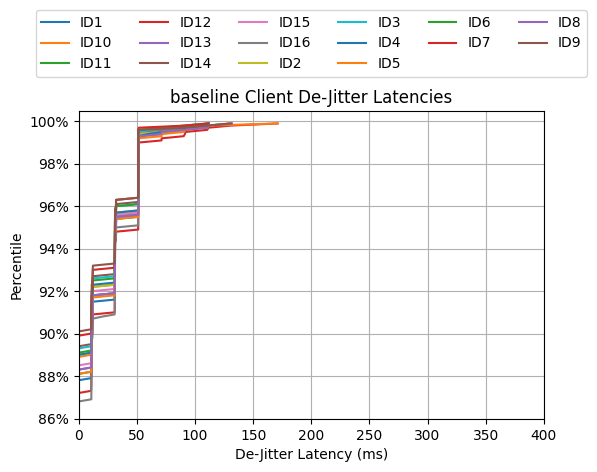

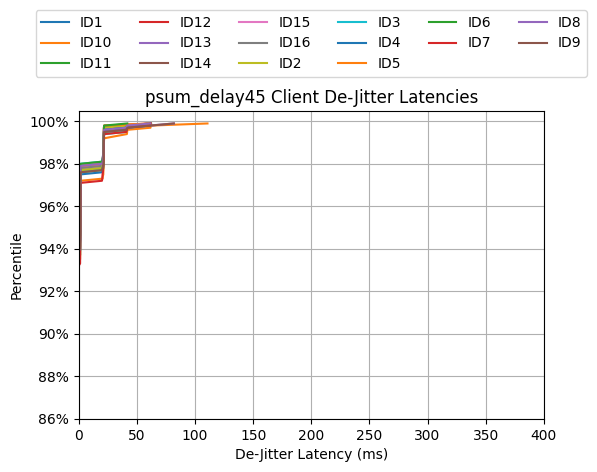

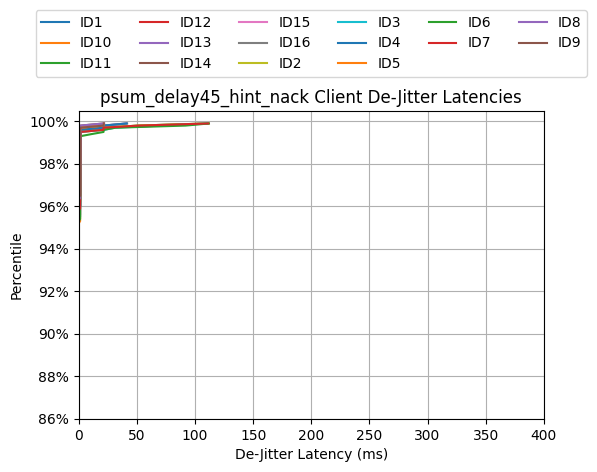

In [29]:
for label in labels:
    for num_clients in [16]:
        plot_delay_cdf(results[label][num_clients], title=f'{label} Client De-Jitter Latencies')

# Plot num clients vs. rx_packets

In [13]:
def plot_num_clients_vs_metric(data, labels, iface='h0-eth0', metric='rx_packets', title=None, ncol=3, ylim=0, delta=25, pdf=None):
    plt.figure(figsize=(6, 4))

    # Plot each label
    for label in labels:
        xs = []
        ys = []

        treatment_data = data[label]
        for num_clients in sorted(treatment_data.keys()):
            output = treatment_data.get(num_clients)
            if not output:
                continue
            xs.append(num_clients)
            assert output['success']
            index = output['statistics']['ifaces'].index(iface)
            ys.append(output['statistics'][metric][index] / output['time_s'])

        plt.plot(xs, ys, marker='.', label=label)

    plt.title(title)
    plt.xlabel('num multicast clients')
    plt.ylabel(f'{metric} / s')
    plt.grid()
    plt.xlim(0)
    plt.ylim(ylim)
    plot_title_and_legend(title, labels, base_height=1.13, row_height=0.07, title_height=0.08, ncol=ncol)
    if pdf:
        save_pdf(pdf)
    plt.show()

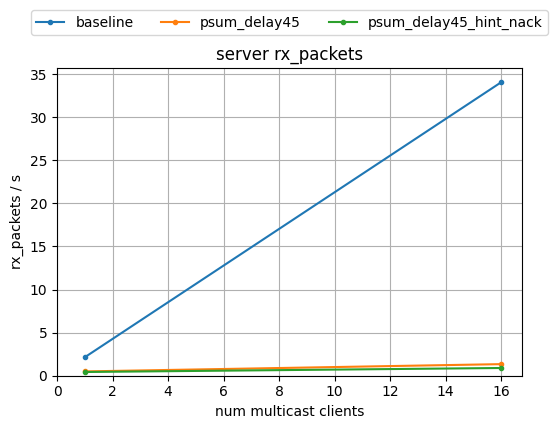

In [35]:
plot_num_clients_vs_metric(results, labels, iface='h0-eth0', title='server rx_packets')

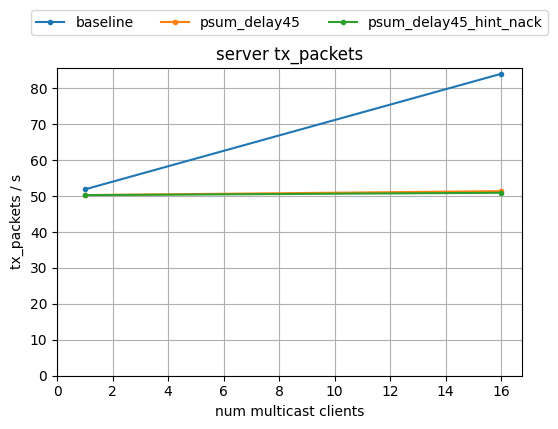

In [34]:
plot_num_clients_vs_metric(results, labels, metric='tx_packets', iface='h0-eth0', title='server tx_packets')

# Plot network statistics

In [62]:
def plot_network_statistics_one_trial(output, title, statistic):
    output = output['statistics']
    data = {}
    for i, iface in enumerate(output['ifaces']):
        data[iface] = output[statistic][i]
    ifaces = list(sorted(filter(lambda iface: iface.startswith('h'), output['ifaces'])))
    width = 0.8 / len(ifaces)
    for i, iface in enumerate(ifaces):
        value = data[iface]
        plt.bar([i * width], value, width=width, label=iface)

    plt.ylabel(statistic)
    plt.ylim(0)

    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=5)
    plt.show()

In [64]:
def plot_network_statistics(labels, results, ifaces, statistic, title):
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        output = results[label]['statistics']
        values = []
        for index, iface in enumerate(output['ifaces']):
            if iface in ifaces:
                values.append(output[statistic][index])
        mean = statistics.mean(values)
        std = None if len(values) <= 1 else statistics.stdev(values)
        plt.bar([i * width], mean, yerr=std, width=width, label=label)

    plt.ylabel(statistic)
    plt.ylim(0)
    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
    plt.show()

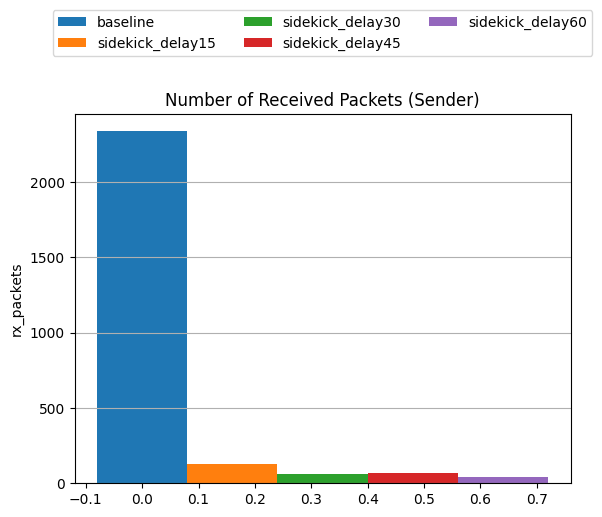

In [81]:
# Number of received packets at h0-eth0 for each treatment
# The multicast sender processes much fewer NACKs per second
plot_network_statistics(labels, results, ifaces=['h0-eth0'], statistic='rx_packets', title='Number of Received Packets (Sender)')

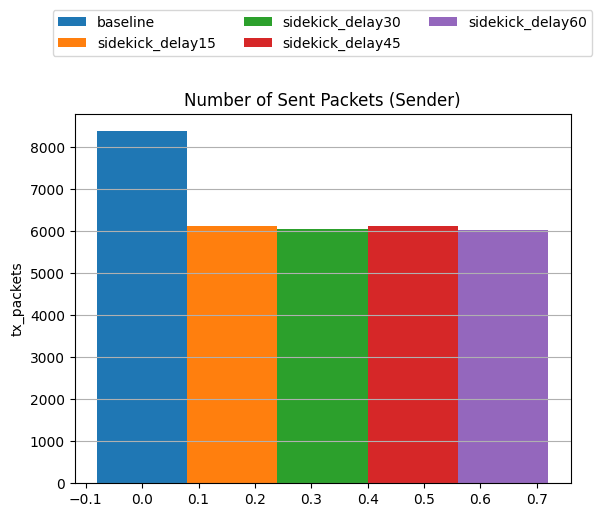

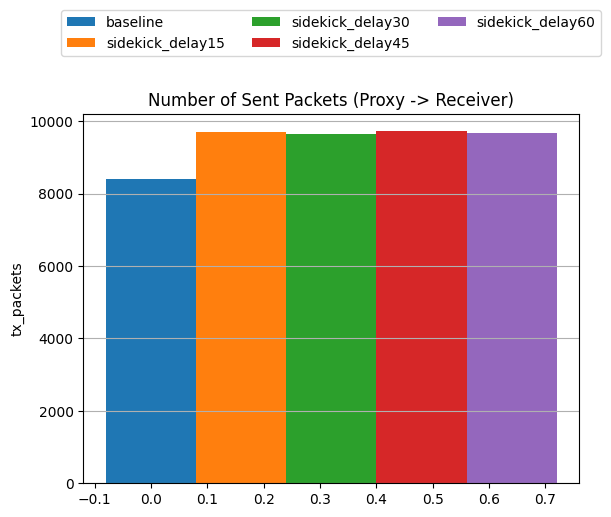

In [96]:
# Number of sent packets at h0-eth0 for each treatment
# Fewer packets saturating the core network
plot_network_statistics(labels, results, ifaces=['h0-eth0'], statistic='tx_packets', title='Number of Sent Packets (Sender)')
plot_network_statistics(labels, results, ifaces=['p1-eth1'], statistic='tx_packets', title='Number of Sent Packets (Proxy -> Receiver)')

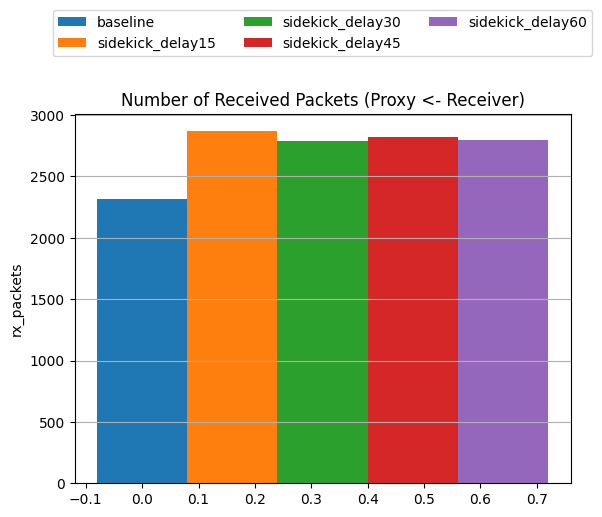

In [94]:
# Number of received packets at p1-eth1 for each treatment
# Low data overheads of using the quACK at the proxy
plot_network_statistics(labels, results, ifaces=['p1-eth1'], statistic='rx_packets', title='Number of Received Packets (Proxy <- Receiver)')

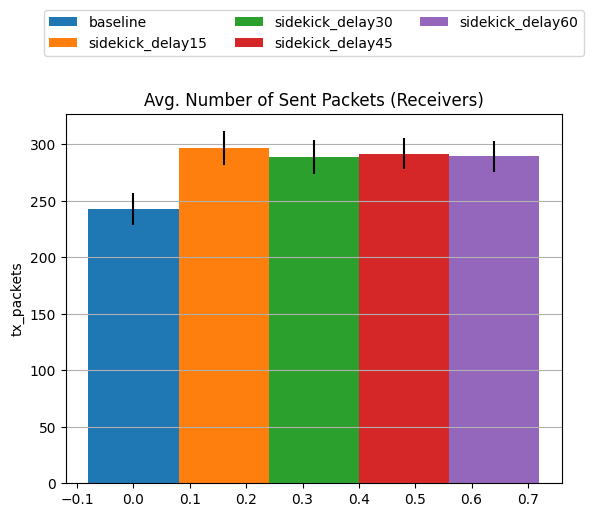

In [93]:
# Average number of sent packets at h1-eth0 to h10-eth0 for each treatment
plot_network_statistics(labels, results, ifaces=[f'h{i}-eth0' for i in range(1, 11)], statistic='tx_packets', title='Avg. Number of Sent Packets (Receivers)')

In [84]:
# output = results['baseline']
# plot_network_statistics_one_trial(output, title='Number of Sent Packets', statistic='tx_packets')
# plot_network_statistics_one_trial(output, title='Number of Received Packets', statistic='rx_packets')

In [85]:
# output = results['sidekick']
# plot_network_statistics_one_trial(output, title='Number of Sent Packets', statistic='tx_packets')
# plot_network_statistics_one_trial(output, title='Number of Received Packets', statistic='rx_packets')

Number of sent packets:
* h0-eth0-send = frequency * time
* hn-eth0-send = h0-eth0-send * loss

Number of received packets:
* h0-eth0-recv = hn-eth0-send * num_clients
* hn-eth0-recv = h0-eth0-send - hn-eth0-send

# Plot num spurious

In [89]:
def plot_num_spurious(labels, results, title):
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        values = results[label]['num_spurious']
        mean = statistics.mean(values)
        std = None if len(values) <= 1 else statistics.stdev(values)
        plt.bar([i * width], mean, yerr=std, width=width, label=label)

    plt.ylabel('Num Packets')
    plt.ylim(0)
    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
    plt.show()

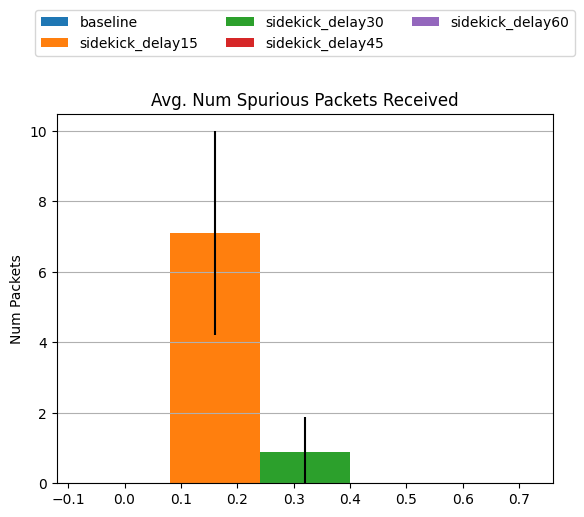

In [91]:
plot_num_spurious(labels, results, title="Avg. Num Spurious Packets Received")